44
['K', 'Γ', 'M', 'K', 'Γ']


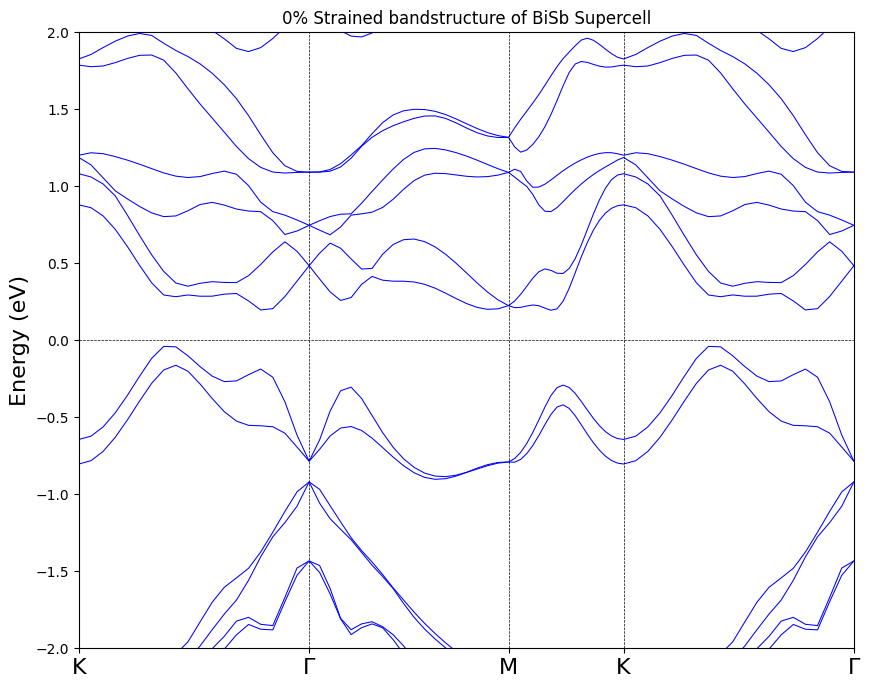

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0, 1.007,1.879,2.382,3.389]  
high_symmetry_labels = ["K", "Γ", "M", "K", "Γ"]

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=0.75)

plt.axhline(0, color='black', linestyle='--', lw=0.5)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.title("0% Strained bandstructure of BiSb Supercell")
plt.ylabel('Energy (eV)', fontsize=16)
plt.ylim(-2, 2)
plt.xlim(min(k),max(k))
plt.show()

Number of bands below Fermi level in DFT data: 32


(-3.0, 3.0)

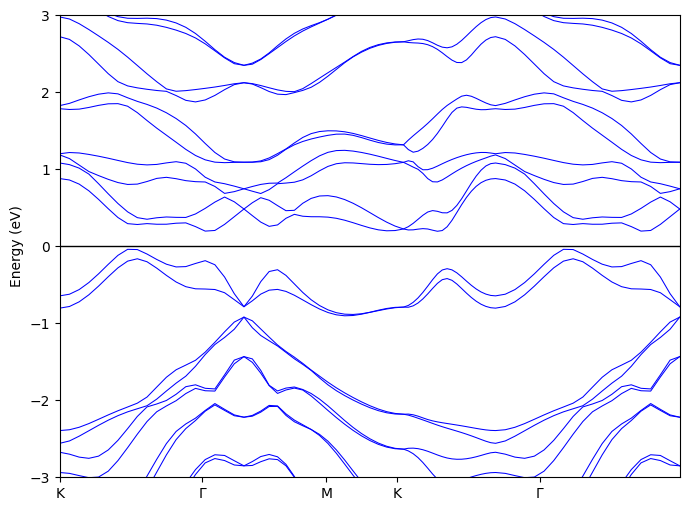

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data_dft = np.loadtxt("REFORMATTED_BAND.dat")
data_wan = np.loadtxt("bisbtes-wannier90_band.dat")

k_dft = data_dft[:, 0]
band_dft = data_dft[:, 1:]

k_wan = np.unique(data_wan[:, 0])
bands_wan = np.reshape(data_wan[:, 1], (-1, len(k_wan)))

high_symmetry_points = [0,0.780,1.456,1.846,2.626]
high_sym_labels = ['K',r'$\Gamma$','M', 'K', r'$\Gamma$',]

k_wan = k_wan * (max(k_dft) / max(k_wan))

#number of bands below fermi level in DFT data
num_bands_below_fermi = np.sum(band_dft[0, :] < 0) 
print(f"Number of bands below Fermi level in DFT data: {num_bands_below_fermi}")

plt.figure(figsize=(8,6))

for i in range(band_dft.shape[1]):
    plt.plot(k_dft, band_dft[:, i], color='blue', linewidth=0.75, label='DFT' if i == 0 else "")
  
#for i in range(bands_wan.shape[0]):
    #plt.plot(k_wan, bands_wan[i, :]+1.3555, color='red', linestyle='--', linewidth=0.75, label='Wannier90' if i == 0 else "")


plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.xticks(high_symmetry_points, high_sym_labels)
plt.ylabel('Energy (eV)')
#plt.title('Band Structure for $\epsilon$ = 24', fontsize=16)
plt.xlim(min(k_dft), max(k_dft))
plt.ylim(-3, 3)


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2025-12-26 18:29:56,123                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(30, 101, 5)                                |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

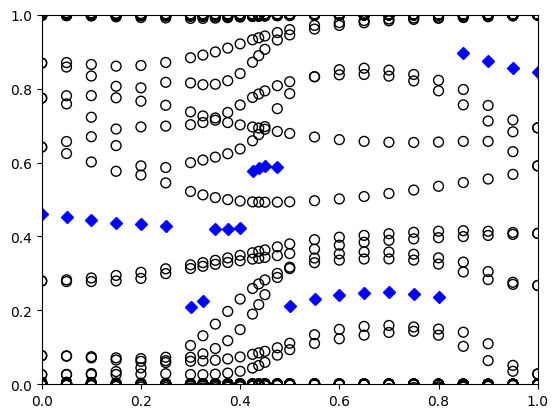

In [7]:
import z2pack
import tbmodels # type: ignore
import matplotlib.pyplot as plt

model = tbmodels.Model.from_wannier_files(hr_file='bisbtes-wannier90_hr.dat', wsvec_file='bisbtes-wannier90_wsvec.dat',occ=32)

system = z2pack.tb.System(model)
result = z2pack.surface.run(system=system, surface=lambda t1,t2: [t1/2, t2, 0.5],num_lines=21,iterator=range(30, 101, 5))

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show()